# 05 — Intermediary Hub Analysis

**Research question:** Which intermediary brokers are the most central nodes in the offshore network, and do a small number of firms account for a disproportionate share of activity?

**Approach:**
1. Degree centrality — how many entities does each intermediary connect to?
2. Concentration analysis — do the top N intermediaries account for most connections (Pareto-style)?
3. Geographic distribution — where are the dominant intermediaries based?
4. Leak source breakdown — are certain intermediaries concentrated in specific leaks?
5. Mini network visualization of the top intermediaries

## 0 — Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/Users/jonasthieme/Documents/GitHub/QSS20-S26/QSS20FinalProject/full-oldb.LATEST/'

relationships = pd.read_csv(BASE_PATH + 'relationships.csv', low_memory=False)
intermeds     = pd.read_csv(BASE_PATH + 'nodes-intermediaries.csv', low_memory=False)
entities      = pd.read_csv(BASE_PATH + 'nodes-entities.csv', low_memory=False)

print(f"Relationships: {relationships.shape}")
print(f"Intermediaries: {intermeds.shape}")
print(f"Entities: {entities.shape}")
print(f"\nIntermediary columns: {list(intermeds.columns)}")

Relationships: (3339267, 8)
Intermediaries: (25629, 10)
Entities: (814344, 21)

Intermediary columns: ['node_id', 'name', 'status', 'internal_id', 'address', 'countries', 'country_codes', 'sourceID', 'valid_until', 'note']


## 1 — Leak Source Filter

In [2]:
LEAK_SOURCES = [
    'Panama Papers',
    'Pandora Papers - Alemán, Cordero, Galindo & Lee (Alcogal)',
    'Pandora Papers - SFM Corporate Services',
    'Pandora Papers - Trident Trust',
    'Pandora Papers - Commence Overseas',
    'Pandora Papers - Alpha Consulting',
    'Pandora Papers - Fidelity Corporate Services',
    'Pandora Papers - CILTrust International',
    'Pandora Papers - Il Shin Corporate Consulting Limited',
    'Pandora Papers - Overseas Management Company (OMC)',
    'Pandora Papers - Asiaciti Trust',
    'Paradise Papers - Appleby',
    'Offshore Leaks',
    'Bahamas Leaks'
]

intermeds_leaks = intermeds[intermeds['sourceID'].isin(LEAK_SOURCES)].copy()
entities_leaks  = entities[entities['sourceID'].isin(LEAK_SOURCES)].copy()

print(f"Intermediaries after filter: {len(intermeds_leaks):,} (was {len(intermeds):,})")
print(f"Entities after filter:       {len(entities_leaks):,}")

Intermediaries after filter: 24,246 (was 25,629)
Entities after filter:       549,194


## 2 — Degree Centrality: Entities per Intermediary

In [3]:
# Pull intermediary_of links
intermed_links = relationships[
    relationships['rel_type'] == 'intermediary_of'
][['node_id_start', 'node_id_end']]

print(f"Total intermediary_of links: {len(intermed_links):,}")

# Count entities per intermediary (degree centrality)
degree = (
    intermed_links
    .groupby('node_id_start')
    .size()
    .reset_index(name='entity_count')
)

# Merge in intermediary metadata
degree = degree.merge(
    intermeds_leaks[['node_id', 'name', 'countries', 'sourceID', 'status']],
    left_on='node_id_start', right_on='node_id',
    how='inner'   # inner = only leak-filtered intermediaries
).drop(columns='node_id')

degree = degree.sort_values('entity_count', ascending=False).reset_index(drop=True)

print(f"\nIntermediaries with at least one link: {len(degree):,}")
print(f"\nTop 20 intermediaries by entity count:")
print(degree[['name','countries','sourceID','entity_count']].head(20).to_string(index=False))

Total intermediary_of links: 598,546

Intermediaries with at least one link: 24,210

Top 20 intermediaries by entity count:
                                        name      countries       sourceID  entity_count
     MOSSACK FONSECA & CO. (BAHAMAS) LIMITED        Bahamas  Bahamas Leaks         14901
                 UBS TRUSTEES (BAHAMAS) LTD.        Bahamas  Bahamas Leaks          9717
                 CREDIT SUISSE TRUST LIMITED        Bahamas  Bahamas Leaks          8299
        TRIDENT CORPORATE SERVICES (BAH) LTD        Bahamas  Bahamas Leaks          8286
                            MMG BAHAMAS LTD.        Bahamas  Bahamas Leaks          8149
           ORION HOUSE SERVICES (HK) LIMITED      Hong Kong  Panama Papers          7016
            Unitrust Corporate Services Ltd. United Kingdom Offshore Leaks          5699
              K.M.C. CORPORATE SERVICES LTD.        Bahamas  Bahamas Leaks          5318
    ** DISABLED SUISSE SECURITY BANK & TRUST        Bahamas  Bahamas Leaks 

## 3 — Concentration Analysis

In [4]:
total_links = degree['entity_count'].sum()

# Cumulative share
degree['cumulative_share'] = degree['entity_count'].cumsum() / total_links

# How many intermediaries account for 50% / 80% / 90% of all links?
for threshold in [0.25, 0.50, 0.75, 0.90]:
    n = (degree['cumulative_share'] <= threshold).sum() + 1
    pct_of_total = n / len(degree) * 100
    print(f"Top {n:>4} intermediaries ({pct_of_total:.1f}% of all) account for {threshold:.0%} of links")

print(f"\nTotal intermediaries: {len(degree):,}")
print(f"Total links:          {total_links:,}")
print(f"Top 1 intermediary:   {degree.iloc[0]['name']} — {degree.iloc[0]['entity_count']:,} entities")

Top   23 intermediaries (0.1% of all) account for 25% of links
Top  128 intermediaries (0.5% of all) account for 50% of links
Top  692 intermediaries (2.9% of all) account for 75% of links
Top 3093 intermediaries (12.8% of all) account for 90% of links

Total intermediaries: 24,210
Total links:          494,463
Top 1 intermediary:   MOSSACK FONSECA & CO. (BAHAMAS) LIMITED — 14,901 entities


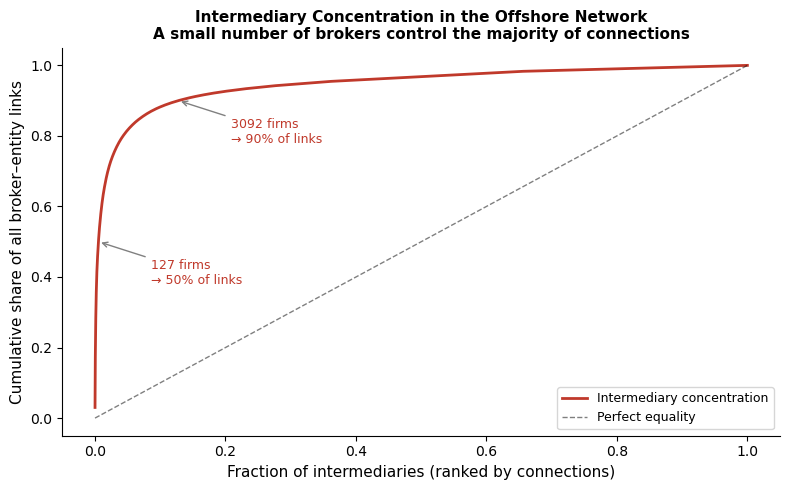

In [7]:
# ── Lorenz-style concentration plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

x = np.linspace(0, 1, len(degree))
ax.plot(x, degree['cumulative_share'].values, color='#c0392b', linewidth=2,
        label='Intermediary concentration')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfect equality')

# Annotate 50% and 90% thresholds
for threshold, label_text in [(0.50, '50%'), (0.90, '90%')]:
    idx = (degree['cumulative_share'] <= threshold).sum()
    x_val = idx / len(degree)
    ax.annotate(
        f"{idx} firms\n→ {label_text} of links",
        xy=(x_val, threshold),
        xytext=(x_val + 0.08, threshold - 0.12),
        arrowprops=dict(arrowstyle='->', color='gray'),
        fontsize=9, color='#c0392b'
    )

ax.set_xlabel('Fraction of intermediaries (ranked by connections)', fontsize=11)
ax.set_ylabel('Cumulative share of all broker–entity links', fontsize=11)
ax.set_title('Intermediary Concentration in the Offshore Network\n'
             'A small number of brokers control the majority of connections',
             fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../output/viz9_intermediary_concentration.png', dpi=150)
plt.show()

## 4 — Top Intermediaries: Bar Chart

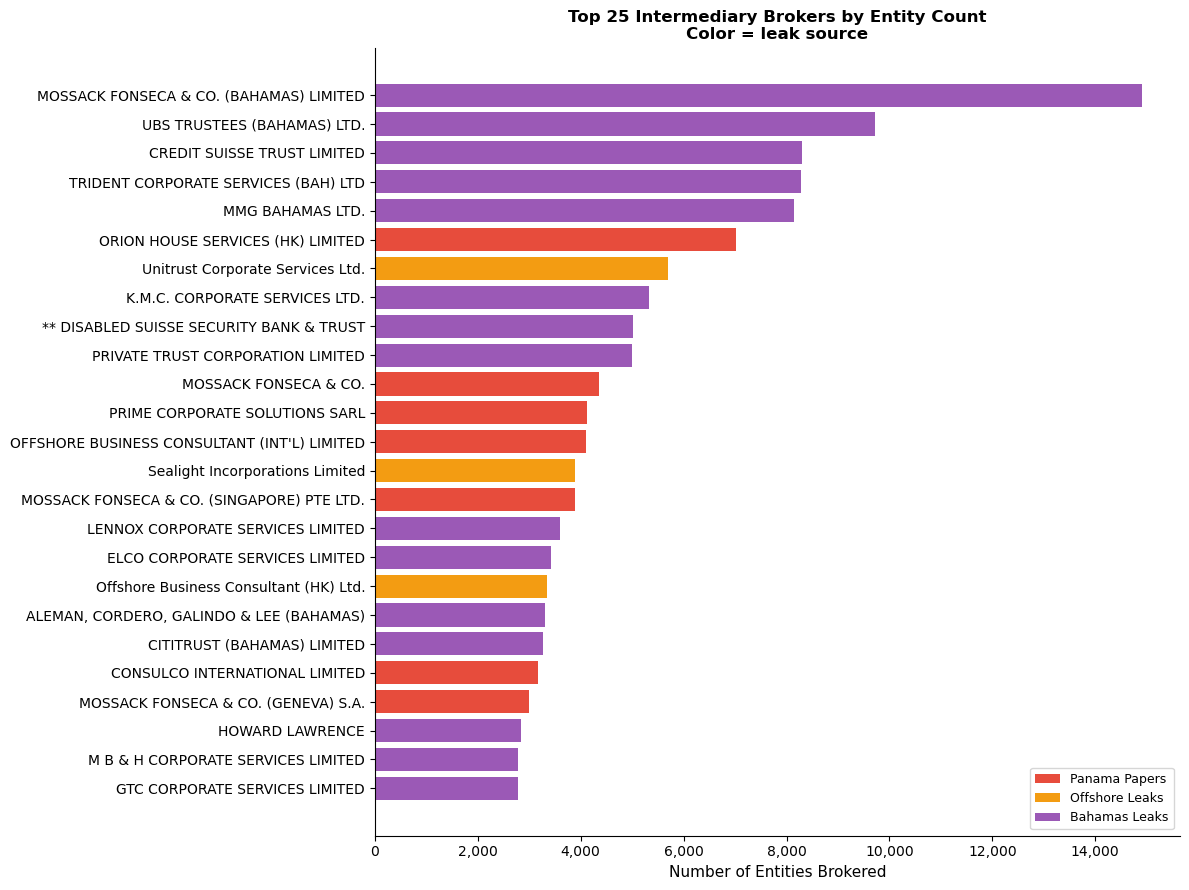

In [8]:
# Simplify source labels
def simplify_source(s):
    if pd.isna(s):       return 'Unknown'
    if 'Pandora' in s:   return 'Pandora Papers'
    return s

degree['source_simplified'] = degree['sourceID'].apply(simplify_source)

top25 = degree.head(25).copy()

# Color by leak source
source_colors = {
    'Panama Papers':       '#e74c3c',
    'Pandora Papers':      '#3498db',
    'Paradise Papers - Appleby': '#2ecc71',
    'Offshore Leaks':      '#f39c12',
    'Bahamas Leaks':       '#9b59b6',
    'Unknown':             '#95a5a6',
}
colors = [source_colors.get(s, '#95a5a6') for s in top25['source_simplified']]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(top25['name'][::-1], top25['entity_count'][::-1], color=colors[::-1])
ax.set_xlabel('Number of Entities Brokered', fontsize=11)
ax.set_title('Top 25 Intermediary Brokers by Entity Count\n'
             'Color = leak source', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in source_colors.items()
                   if s in top25['source_simplified'].values]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../output/viz10_top_intermediaries.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Geographic Distribution of Top Intermediaries

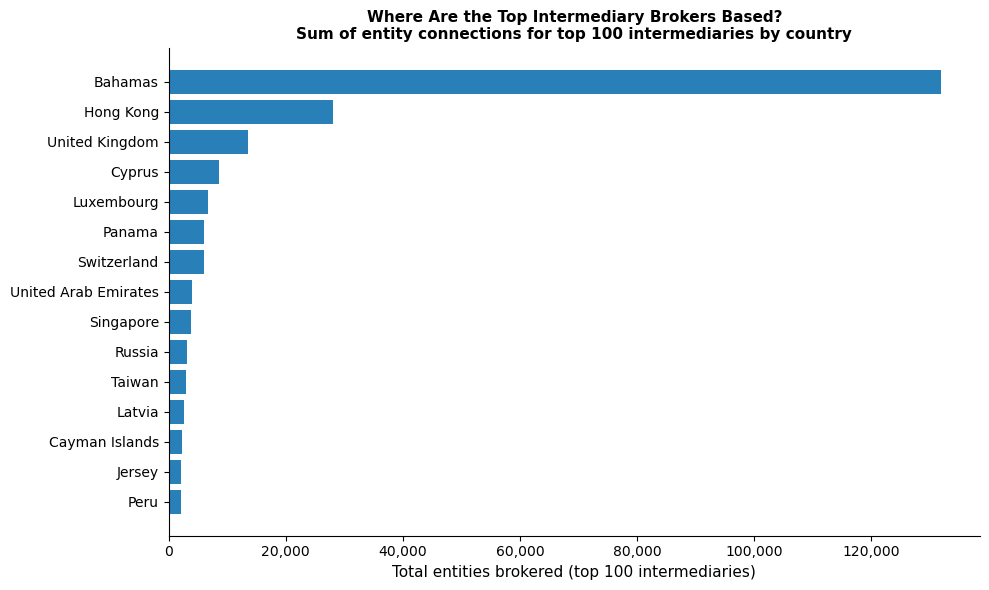


Top 15 intermediary countries (by brokered entity volume):
countries
Bahamas                 131963
Hong Kong                28012
United Kingdom           13494
Cyprus                    8673
Luxembourg                6739
Panama                    6085
Switzerland               6050
United Arab Emirates      4060
Singapore                 3888
Russia                    3150
Taiwan                    2903
Latvia                    2552
Cayman Islands            2295
Jersey                    2160
Peru                      2055


In [10]:
# Country of top 100 intermediaries by volume
top100 = degree.head(100).copy()

# Explode semicolon-joined countries
top100['countries'] = top100['countries'].str.split(';')
top100_exploded = top100.explode('countries')
top100_exploded['countries'] = top100_exploded['countries'].str.strip()

country_counts = (
    top100_exploded[
        top100_exploded['countries'].notna() &
        ~top100_exploded['countries'].isin(['Not identified', 'Not Identified', ''])
    ]
    .groupby('countries')['entity_count']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(country_counts.index[::-1], country_counts.values[::-1], color='#2980b9')
ax.set_xlabel('Total entities brokered (top 100 intermediaries)', fontsize=11)
ax.set_title('Where Are the Top Intermediary Brokers Based?\n'
             'Sum of entity connections for top 100 intermediaries by country',
             fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../output/viz11_intermediary_countries.png', dpi=150)
plt.show()

print("\nTop 15 intermediary countries (by brokered entity volume):")
print(country_counts.to_string())

## 6 — Summary Table for Paper

In [11]:
# Concentration stats
rows = []
for threshold in [0.25, 0.50, 0.75, 0.90]:
    n = (degree['cumulative_share'] <= threshold).sum() + 1
    rows.append({
        'Share of total links': f'{threshold:.0%}',
        'Number of intermediaries': n,
        'As % of all intermediaries': f'{n/len(degree)*100:.1f}%'
    })

concentration_table = pd.DataFrame(rows)
print("=== Concentration Table ===")
print(concentration_table.to_string(index=False))

# Top 10 summary
top10_table = degree[['name','countries','source_simplified','entity_count']].head(10).copy()
top10_table.columns = ['Intermediary', 'Country', 'Leak Source', 'Entities Brokered']
print("\n=== Top 10 Intermediaries ===")
print(top10_table.to_string(index=False))

concentration_table.to_csv('../output/table4_intermediary_concentration.csv', index=False)
top10_table.to_csv('../output/table5_top_intermediaries.csv', index=False)
degree.to_csv('../output/intermediary_degree_full.csv', index=False)
print("\nSaved: table4, table5, intermediary_degree_full.csv")

=== Concentration Table ===
Share of total links  Number of intermediaries As % of all intermediaries
                 25%                        23                       0.1%
                 50%                       128                       0.5%
                 75%                       692                       2.9%
                 90%                      3093                      12.8%

=== Top 10 Intermediaries ===
                            Intermediary        Country    Leak Source  Entities Brokered
 MOSSACK FONSECA & CO. (BAHAMAS) LIMITED        Bahamas  Bahamas Leaks              14901
             UBS TRUSTEES (BAHAMAS) LTD.        Bahamas  Bahamas Leaks               9717
             CREDIT SUISSE TRUST LIMITED        Bahamas  Bahamas Leaks               8299
    TRIDENT CORPORATE SERVICES (BAH) LTD        Bahamas  Bahamas Leaks               8286
                        MMG BAHAMAS LTD.        Bahamas  Bahamas Leaks               8149
       ORION HOUSE SERVICES (HK

## Notes for Paper (Methods / Results section)

- **Degree centrality:** Each intermediary's degree is the count of unique entities it is connected to via `intermediary_of` relationships. This is an undirected degree measure — it counts how many shells a broker set up or administered.
- **Concentration:** The Lorenz-style curve shows what fraction of all broker–entity links is accounted for by the top N% of intermediaries. A curve far from the diagonal indicates high concentration.
- **Geographic attribution:** Intermediary country comes from the `countries` field in `nodes-intermediaries.csv`. Semicolon-joined multi-country entries are exploded before aggregation.
- **Limitation:** Degree centrality measures raw connection count, not weighted by entity size or monetary value. A firm that set up 10,000 small shells appears more central than one that set up 100 large ones.